In [27]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

import numpy as np
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

In [28]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [29]:
multiplier_4151 = 1
multiplier_1068 = 1

# Exposure changes count statistics, not the intrinsic spectra plotted below.
exposure_4151 = multiplier_4151 * 3
exposure_1068 = multiplier_1068 * 3

# Source Model Plots

## Cutoff Power Law (Thermal)

### NGC 4151 Faint

In [30]:
K_inj = 0.035 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj_faint = Cutoff_powerlaw()

spectrum_inj_faint.K.value = K_inj.value
spectrum_inj_faint.piv.value = piv_inj.value
spectrum_inj_faint.xc.value = xc_inj.value
spectrum_inj_faint.index.value = index_inj

spectrum_inj_faint.K.unit = K_inj.unit
spectrum_inj_faint.piv.unit = piv_inj.unit
spectrum_inj_faint.xc.unit = xc_inj.unit

print(spectrum_inj_faint.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_faint).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_faint.K.value
    * (200.0 / spectrum_inj_faint.piv.value) ** spectrum_inj_faint.index.value
)

print(K_inj_at_fit_pivot)

1.9604007311633674e-06
energy_flux:  2.2625945051666873e-10 erg / (s cm2)
energy_flux_err:  3.911404985862341e-21 erg / (s cm2)
2.3944388601421497e-06


### NGC 4151 Bright

In [31]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1 * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj_bright = Cutoff_powerlaw()

spectrum_inj_bright.K.value = K_inj.value
spectrum_inj_bright.piv.value = piv_inj.value
spectrum_inj_bright.xc.value = xc_inj.value
spectrum_inj_bright.index.value = index_inj

spectrum_inj_bright.K.unit = K_inj.unit
spectrum_inj_bright.piv.unit = piv_inj.unit
spectrum_inj_bright.xc.unit = xc_inj.unit

print(spectrum_inj_bright.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_bright).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_bright.K.value
    * (200.0 / spectrum_inj_bright.piv.value) ** spectrum_inj_bright.index.value
)

print(K_inj_at_fit_pivot)

8.171823827880958e-06
energy_flux:  4.389534680806134e-10 erg / (s cm2)
energy_flux_err:  2.2263070941985436e-20 erg / (s cm2)
1.743130759098566e-05


### Case 2

#### NGC 4151 (200 keV)

In [32]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [33]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

#### NGC 4151 (200 keV)

In [ ]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = 0.12*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -2.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200,
    spectrum_inj_ec200_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200.evaluate_at(E), 100.0, 10000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL.evaluate_at(E), 100.0, 10000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    100.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  3.3721558756085362e-06 1 / (keV s cm2)
5.187932116320825e-06
3.3721558756085362e-06
Linking K ratio 0.23912163676143755
Flux ratio at 200 keV 0.65
Non-thermal energy flux:  4.5852572127267055e-10 erg / (s cm2)
Total energy flux:  9.615478273462703e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  1.0970422873496088
Non-thermal energy flux percentage:  0.4768621052767949
energy_flux:  9.6154782734627e-10 erg / (s cm2)
energy_flux_err:  4.815516752245129e-19 erg / (s cm2)
1.4102261599073975e-05


In [ ]:
# # Replace the hard step with a continuous broken power law.
# # Below 200 keV the positive index suppresses the tail smoothly; above
# # 200 keV the model retains the original -3.8 non-thermal slope.

# spectrum_inj_ec200_PL_unbroken = spectrum_inj_ec200_PL

# break_energy = 400.0 * u.keV
# index_below_break = -3
# index_above_break = spectrum_inj_ec200_PL_unbroken.index.value
# K_at_break = (
#     spectrum_inj_ec200_PL_unbroken.evaluate_at(break_energy.value)
#     / u.cm / u.cm / u.s / u.keV
# )

# spectrum_inj_ec200_BPL = Broken_powerlaw()
# spectrum_inj_ec200_BPL.K.value = K_at_break.value
# spectrum_inj_ec200_BPL.xb.value = break_energy.value
# spectrum_inj_ec200_BPL.piv.value = break_energy.value
# spectrum_inj_ec200_BPL.alpha.value = index_below_break
# spectrum_inj_ec200_BPL.beta.value = index_above_break
# spectrum_inj_ec200_BPL.K.unit = K_at_break.unit
# spectrum_inj_ec200_BPL.xb.unit = break_energy.unit
# spectrum_inj_ec200_BPL.piv.unit = break_energy.unit

# # Keep the existing variable name so the plotting cells below use the BPL.
# spectrum_inj_ec200_PL = spectrum_inj_ec200_BPL
# spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

# print("K_inj: ", K_inj)
# print(spectrum_inj_ec200.evaluate_at(200))
# print(spectrum_inj_ec200_PL.evaluate_at(200))
# print("="*40)
# linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
#     spectrum_inj_ec200,
#     spectrum_inj_ec200_PL.piv.value,
# )
# print("Linking K ratio", linking_ratio_ec200)
# print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
# print("="*40)
# energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200.evaluate_at(E), 100.0, 10000.0)
# energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL.evaluate_at(E), 100.0, 10000.0)
# energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# print("Non-thermal energy flux: ", energy_flux_nth)
# print("Total energy flux: ", energy_flux_th + energy_flux_nth)
# print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
# print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

# energy_flux_kev, energy_flux_kev_err = quad(
#     lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
#     200.0,
#     10000.0,
# )

# energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
# energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

# print("energy_flux: ", energy_flux)
# print("energy_flux_err: ", energy_flux_err)

# K_inj_at_fit_pivot = (
#     spectrum_inj_ec200.K.value
#     * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
# )

# print(K_inj_at_fit_pivot)

K_inj:  2.07517284652833e-06 1 / (keV s cm2)
5.187932116320825e-06
1.1918738175708045e-06
Linking K ratio 0.03553481168920669
Flux ratio at 200 keV 0.22973967099940718
Non-thermal energy flux:  1.3572861012921452e-10 erg / (s cm2)
Total energy flux:  6.387507162028143e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  3.7060875050199025
Non-thermal energy flux percentage:  0.21249073650528538
energy_flux:  2.8190390511377627e-10 erg / (s cm2)
energy_flux_err:  6.320819651902248e-18 erg / (s cm2)
1.4102261599073975e-05


#### NGC 4151 (1000 keV)

In [35]:
K_inj = 0.12*spectrum_inj_ec1000.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -2.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec1000 = spectrum_inj_ec1000_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec1000,
    spectrum_inj_ec1000_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec1000)
print("Flux ratio at 200 keV", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec1000.evaluate_at(E), 100.0, 10000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec1000_PL.evaluate_at(E), 100.0, 10000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec1000.K.value
    * (200.0 / spectrum_inj_ec1000.piv.value) ** spectrum_inj_ec1000.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  1.3855146310935058e-06 1 / (keV s cm2)
1.1545955259112548e-05
1.3855146310935069e-06
Linking K ratio 0.09824769036935797
Flux ratio at 200 keV 0.12000000000000009
Non-thermal energy flux:  1.8839404790009702e-10 erg / (s cm2)
Total energy flux:  2.1074644950885054e-09 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  10.186470690443825
Non-thermal energy flux percentage:  0.08939369955657792
energy_flux:  1.5218157329548633e-09 erg / (s cm2)
energy_flux_err:  6.421127542591567e-20 erg / (s cm2)
1.4102261599073975e-05


### Case 3

#### NGC 4151 (200 keV)

In [36]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200_testa = Cutoff_powerlaw()

spectrum_inj_ec200_testa.K.value = K_inj.value
spectrum_inj_ec200_testa.piv.value = piv_inj.value
spectrum_inj_ec200_testa.xc.value = xc_inj.value
spectrum_inj_ec200_testa.index.value = index_inj

spectrum_inj_ec200_testa.K.unit = K_inj.unit
spectrum_inj_ec200_testa.piv.unit = piv_inj.unit
spectrum_inj_ec200_testa.xc.unit = xc_inj.unit

#### NGC 4151 (200 keV) Non-thermal cutoff

In [37]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = 0.1*spectrum_inj_ec200_testa.evaluate_at(1) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
index_inj = -1.7
cutoff_inj = 2000. * u.keV

spectrum_inj_ec200_PL_testa = Cutoff_powerlaw()

spectrum_inj_ec200_PL_testa.K.value = K_inj.value
spectrum_inj_ec200_PL_testa.piv.value = piv_inj.value
spectrum_inj_ec200_PL_testa.index.value = index_inj
spectrum_inj_ec200_PL_testa.xc.value = cutoff_inj.value

spectrum_inj_ec200_PL_testa.K.unit = K_inj.unit
spectrum_inj_ec200_PL_testa.piv.unit = piv_inj.unit
spectrum_inj_ec200_PL_testa.xc.unit = cutoff_inj.unit

spectrum_inj_ec200_testa_total = spectrum_inj_ec200_testa + spectrum_inj_ec200_PL_testa

print(spectrum_inj_ec200_testa.evaluate_at(200))
print(spectrum_inj_ec200_PL_testa.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL_testa.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200_testa,
    spectrum_inj_ec200_PL_testa.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL_testa.evaluate_at(200)/spectrum_inj_ec200_testa.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200_testa + spectrum_inj_ec200_PL_testa).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200_testa.K.value
    * (200.0 / spectrum_inj_ec200_testa.piv.value) ** spectrum_inj_ec200_testa.index.value
)

print(K_inj_at_fit_pivot)

5.187932116320825e-06
1.6547765042367583e-06
Linking K ratio 0.09950124791926825
Flux ratio at 200 keV 0.31896649129832716
Non-thermal energy flux:  3.0938412000782587e-10 erg / (s cm2)
Total energy flux:  5.319431102429317e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  0.7193613887793472
Non-thermal energy flux percentage:  0.5816112927311607
energy_flux:  5.319431102429163e-10 erg / (s cm2)
energy_flux_err:  2.648326826318879e-20 erg / (s cm2)
1.4102261599073975e-05


In [38]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_inj_bright = np.zeros_like(energy)
flux_inj_faint = np.zeros_like(energy)
flux_inj_ec200 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)
flux_inj_ec200_PL = np.zeros_like(energy)
flux_inj_ec1000_PL = np.zeros_like(energy)
flux_inj_ec200_testa = np.zeros_like(energy)
flux_inj_ec200_PL_testa = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_faint[i] = spectrum_inj_faint.evaluate_at(e)
    flux_inj_bright[i] = spectrum_inj_bright.evaluate_at(e)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)
    flux_inj_ec200_testa[i] = spectrum_inj_ec200_testa.evaluate_at(e)
    flux_inj_ec200_PL_testa[i] = spectrum_inj_ec200_PL_testa.evaluate_at(e)

Plot the fitted and injected spectra

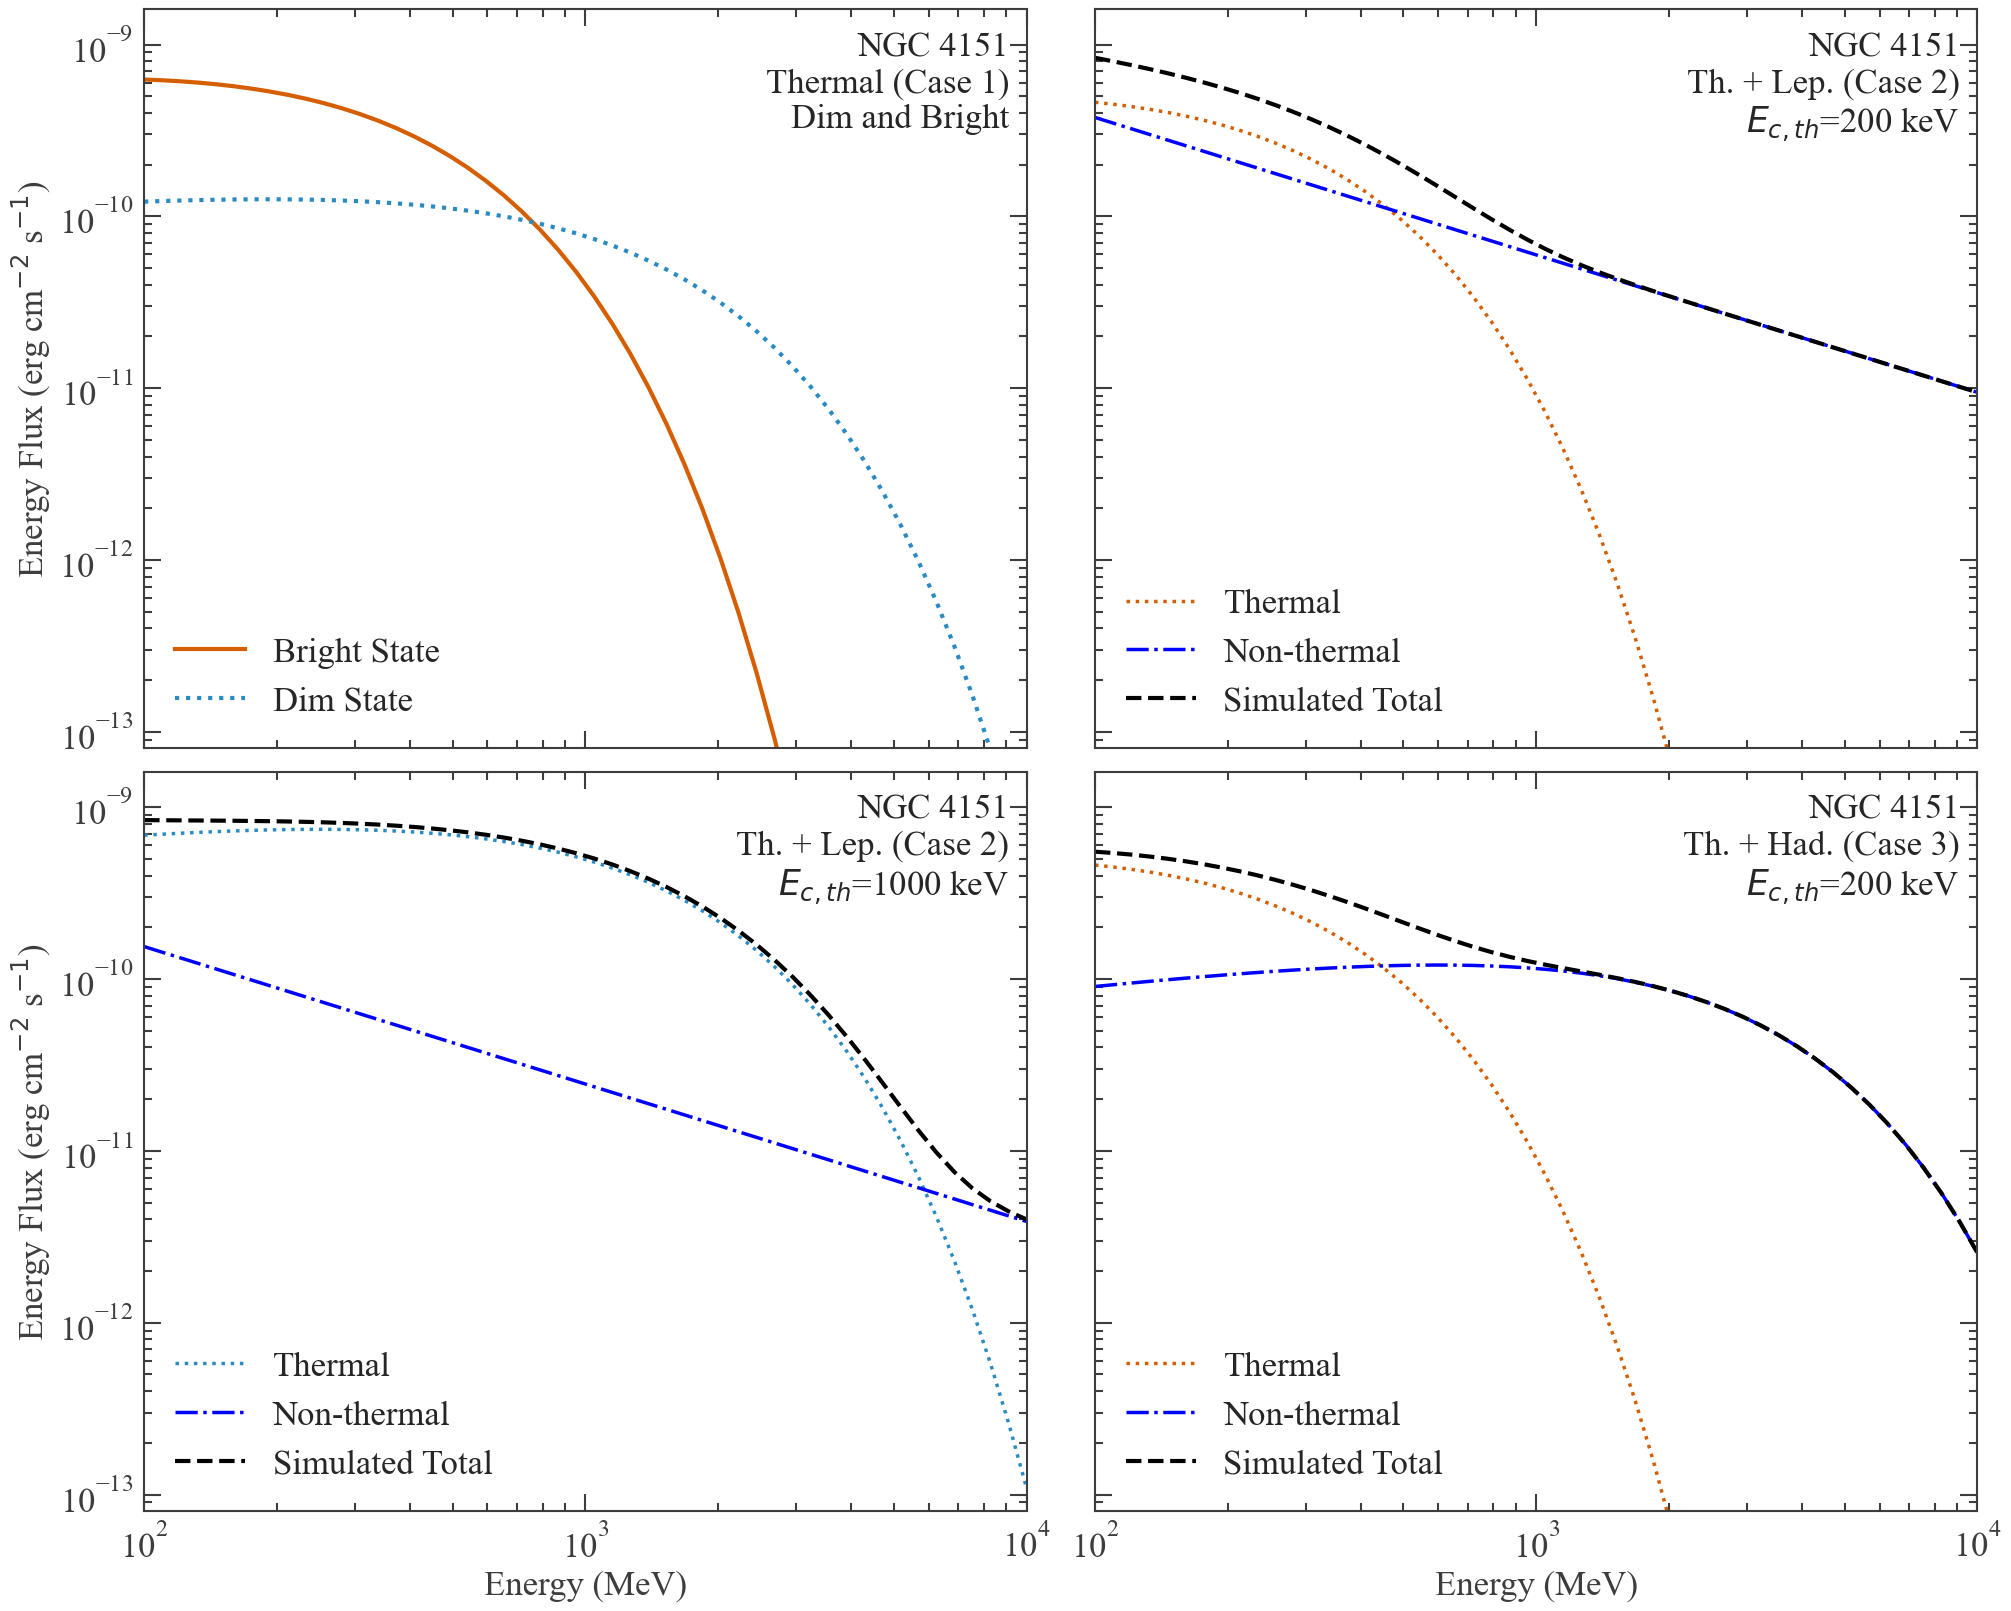

In [39]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 16),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.ravel()

for ax in axes:
    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
    ax.set_xlim(100, 10000)
    # ax.xaxis.set_major_locator(mticker.FixedLocator([100, 5000, 10000]))
    # ax.xaxis.set_major_formatter(
    #     mticker.FixedFormatter(["0.1", "5", "10"])
    # )
    if ax in axes[2:]:
        ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)

axes[0].set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)
axes[2].set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

# Panel 1: thermal dim and bright states.
axes[0].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_bright, color='#D55E00', ls='-', lw=3, label='Bright State')
axes[0].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_faint, color='#2A8BC3', ls=':', lw=3, label='Dim State')
axes[0].text(
    0.98, 0.97,
    'NGC 4151\nThermal (Case 1)\nDim and Bright',
    transform=axes[0].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[0].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Panel 2: Case 2 with a 200 keV thermal cutoff.
axes[1].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200, color='#D55E00', ls=':', lw=2.5, label='Thermal')
axes[1].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_PL, color='blue', ls='-.', lw=2.5, label='Non-thermal')
axes[1].plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec200 + flux_inj_ec200_PL), color='black', ls='--', lw=3, label='Simulated Total')
axes[1].text(
    0.98, 0.97,
    'NGC 4151\nTh. + Lep. (Case 2)\n$E_{c,th}$=200 keV',
    transform=axes[1].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[1].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Panel 3: Case 2 with a 1000 keV thermal cutoff.
axes[2].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000, color='#2A8BC3', ls=':', lw=2.5, label='Thermal')
axes[2].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000_PL, color='blue', ls='-.', lw=2.5, label='Non-thermal')
axes[2].plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec1000 + flux_inj_ec1000_PL), color='black', ls='--', lw=3, label='Simulated Total')
axes[2].text(
    0.98, 0.97,
    'NGC 4151\nTh. + Lep. (Case 2)\n$E_{c,th}$=1000 keV',
    transform=axes[2].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[2].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# Panel 4: Case 3 thermal plus cutoff-power-law non-thermal component.
axes[3].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_testa, color='#D55E00', ls=':', lw=2.5, label='Thermal')
axes[3].plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_PL_testa, color='blue', ls='-.', lw=2.5, label='Non-thermal')
axes[3].plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec200_testa + flux_inj_ec200_PL_testa), color='black', ls='--', lw=3, label='Simulated Total')
axes[3].text(
    0.98, 0.97,
    'NGC 4151\nTh. + Had. (Case 3)\n$E_{c,th}$=200 keV',
    transform=axes[3].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[3].legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/NGC4151_DimBright_Case2_Case3_Four_Panel.pdf"
# plt.savefig(save_path, bbox_inches='tight')


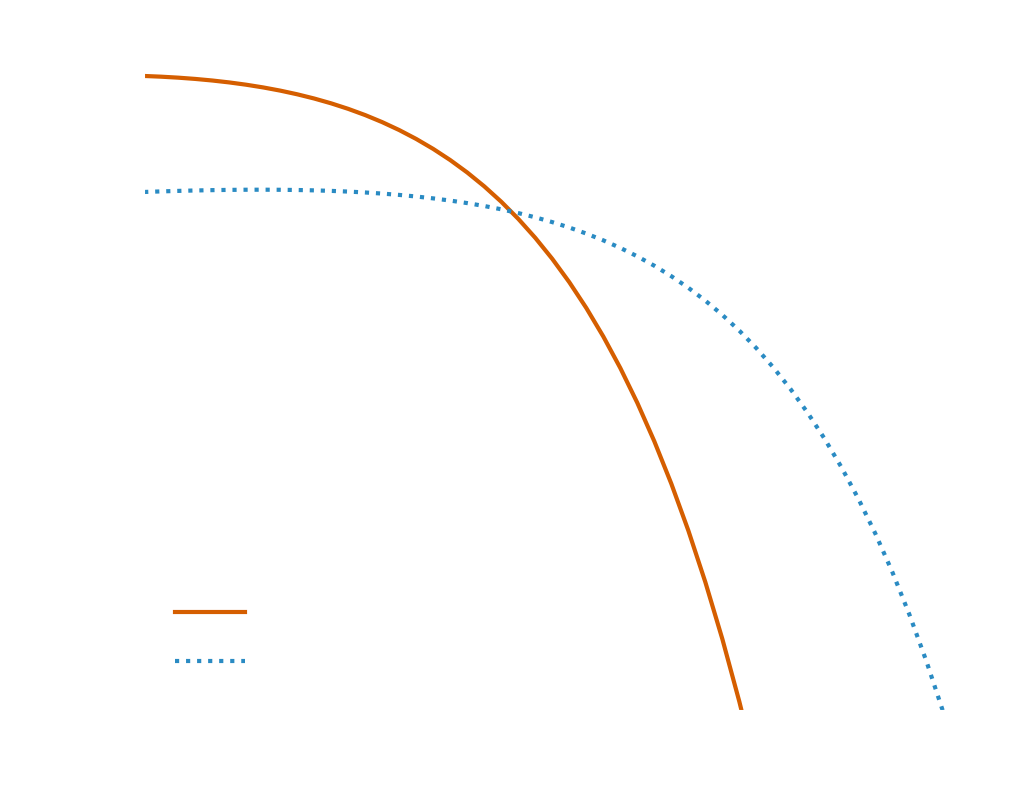

In [23]:
def _apply_transparent_plot_style(fig, ax):
    foreground_color = 'white'

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    ax.tick_params(axis='both', which='both', colors=foreground_color)
    ax.xaxis.label.set_color(foreground_color)
    ax.yaxis.label.set_color(foreground_color)

    for spine in ax.spines.values():
        spine.set_color(foreground_color)

    for annotation in ax.texts:
        annotation.set_color(foreground_color)

    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_alpha(0)
        legend.get_frame().set_edgecolor(foreground_color)
        for legend_text in legend.get_texts():
            legend_text.set_color(foreground_color)


fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(100, 10000)
ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_bright, color='#D55E00', lw=3, label='Bright State')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_faint, color='#2A8BC3', ls=':', lw=3, label='Dim State')
ax.text(
    0.98, 0.97,
    'NGC 4151\nThermal (Case 1)\nDim and Bright',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)
_apply_transparent_plot_style(fig, ax)
plt.show()


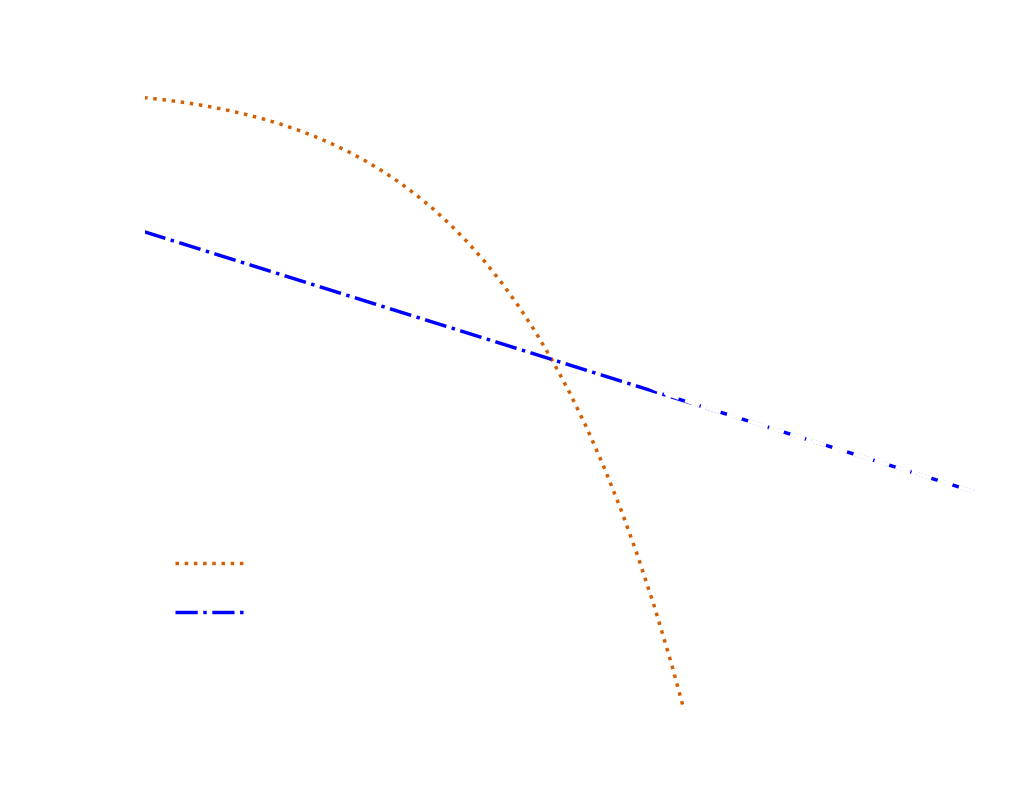

In [24]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(100, 10000)
ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200, color='#D55E00', ls=':', lw=2.5, label='Thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_PL, color='blue', ls='-.', lw=2.5, label='Non-thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec200 + flux_inj_ec200_PL), color='white', ls='--', lw=3, label='Simulated Total')
ax.text(
    0.98, 0.97,
    'NGC 4151\nTh. + Lep. (Case 2)\n$E_{c,th}$=200 keV',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)
_apply_transparent_plot_style(fig, ax)
plt.show()


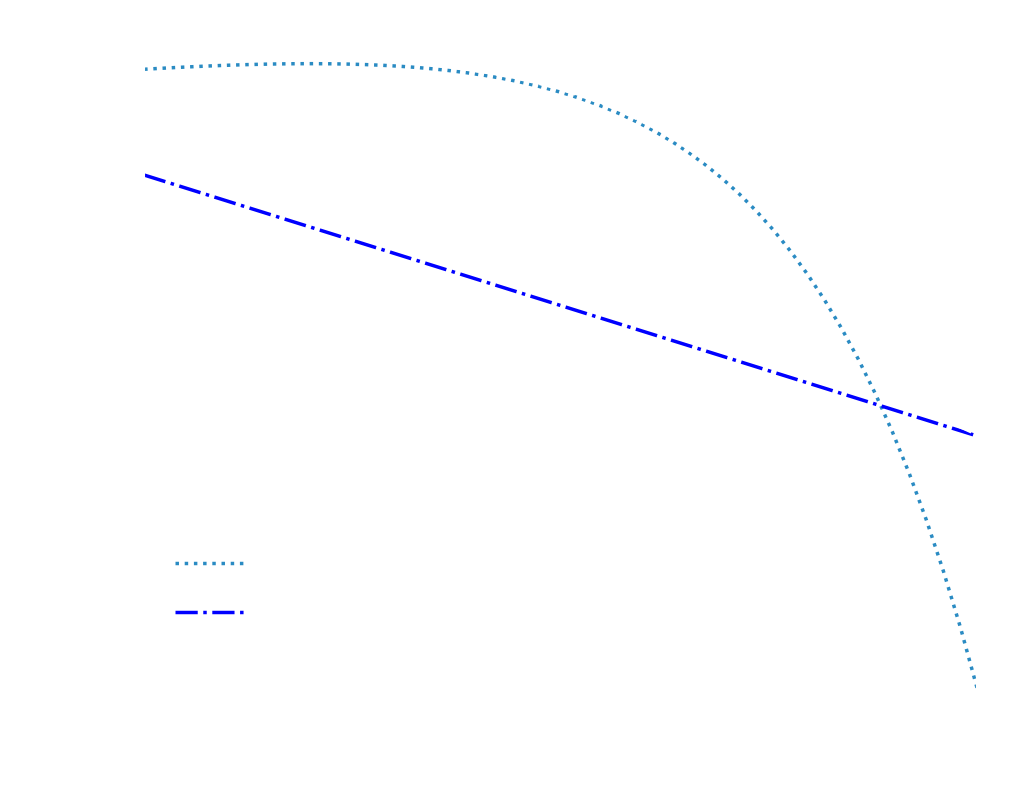

In [25]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(100, 10000)
ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000, color='#2A8BC3', ls=':', lw=2.5, label='Thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec1000_PL, color='blue', ls='-.', lw=2.5, label='Non-thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec1000 + flux_inj_ec1000_PL), color='white', ls='--', lw=3, label='Simulated Total')
ax.text(
    0.98, 0.97,
    'NGC 4151\nTh. + Lep. (Case 2)\n$E_{c,th}$=1000 keV',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)
_apply_transparent_plot_style(fig, ax)
plt.show()


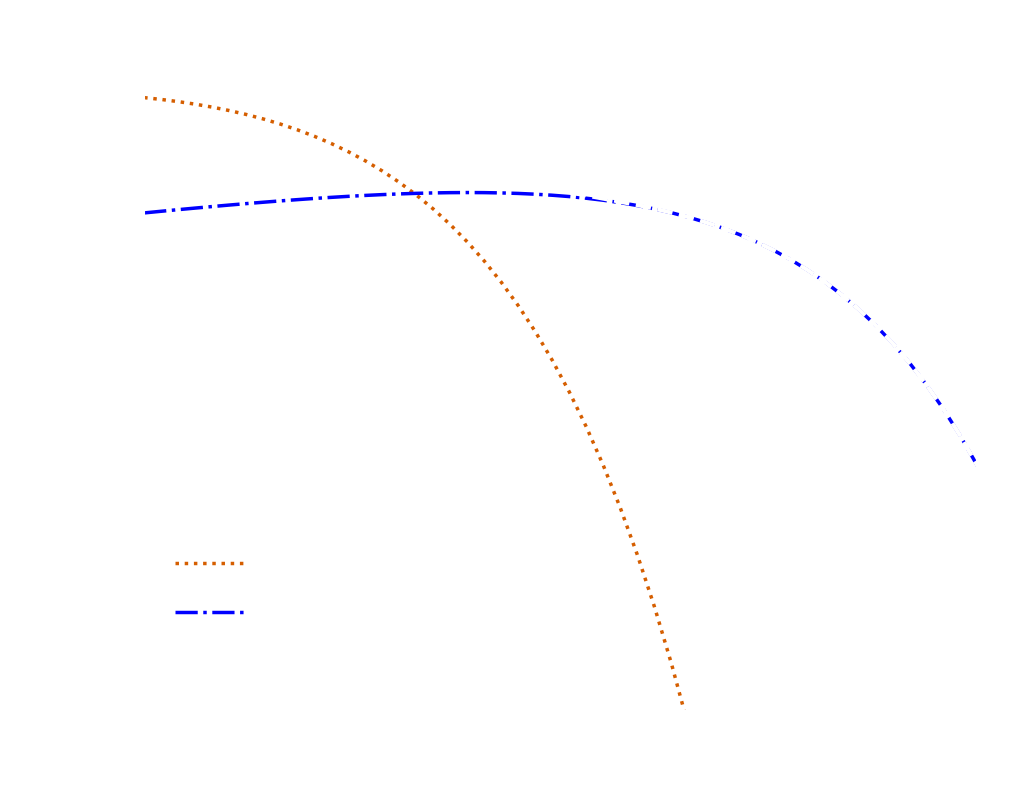

In [26]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(100, 10000)
ax.set_ylim(5e-5 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_testa, color='#D55E00', ls=':', lw=2.5, label='Thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * flux_inj_ec200_PL_testa, color='blue', ls='-.', lw=2.5, label='Non-thermal')
ax.plot(energy, SED_KEV_TO_ERG * energy**2 * (flux_inj_ec200_testa + flux_inj_ec200_PL_testa), color='white', ls='--', lw=3, label='Simulated Total')
ax.text(
    0.98, 0.97,
    'NGC 4151\nTh. + Had. (Case 3)\n$E_{c,th}$=200 keV',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)
_apply_transparent_plot_style(fig, ax)
plt.show()
